# COMP4220: Machine Learning, Fall 2020

# Assignment 3

# Due: Monday, October 19th, 10:00PM

Please submit one pdf file for all questions.

****When turning in assignments after the due date, please clearly specify the number of late hours used.

P1: What are precision and recall?

Precision is the ratio between the true positives and all the positives, i.e. the number we correctly identified among all the positives. It is also known as positive predictive value and is the proportion of relevant instances among the retrieved instances.


Recall is the measure of a model correctly identifying true positives, i.e. for all the positives, recall tells us how many we correctly identified as positive.

SOLTUION: 

Precision is the proportion of true positives out of predicted positives. To put it in another way, it is the accuracy of the prediction. It is also known as the ‘positive predictive value’.
   
  Precision = TP/TP+FP
   
Recall refers to the ratio of positives correctly predicted from all the true labels. In simple words, it is the frequency of correctly predicted true labels.
  
  Recall = TP/TP+FN   
   
Recall is same as the true positive rate (TPR).

P2: Explain the use of ROC curves and the AUC of an ROC Curve.

Receiver Operating Characteristics (ROC) curve plots the true positive rate as a function false positive rate.

Area Under the Curve (AUC) represents degree or measure of seperability. It tells how much the model is capable of distinguishing between classes. The higher the AUC, the better the model is at predicting 0s as 0s and 1s as 1s.

SOLUTION:

An ROC (Receiver Operating Characteristic) curve illustrates the performance of a binary classification model. It is basically a TPR versus FPR (true positive rate versus false-positive rate) curve for all the threshold values ranging from 0 to 1. In a ROC curve, each point in the ROC space will be associated with a different confusion matrix. A diagonal line from the bottom-left to the top-right on the ROC graph represents random guessing. The Area Under the Curve (AUC) signifies how good the classifier model is. If the value for AUC is high (near 1), then the model is working satisfactorily, whereas if the value is low (around 0.5), then the model is not working properly and just guessing randomly.

P3: Programming assignment(Logistic Regression)

This example uses two feature of the Social_Network_Ads dataset that is uploaded along with this Jupyter notebook.

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Importing the dataset
dataset = pd.read_csv('Social_Network_Ads.csv')
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
dataset.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [3]:
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

# checking the shape of the datasets
print("Shape of X :", X.shape)
print('Shape of y :', y.shape)

Shape of X : (400, 2)
Shape of y : (400,)


In [4]:
# checking the shape of the data
dataset.shape

(400, 5)

In [7]:
dataset.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [8]:
# P3.1: Split the dataset into the Training set(%75) and Test set(%25) using "train_test_split" from sklearn.model_selection.

# Use these variables:(X_train, X_test, y_train, y_test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# getting the shapes of newly created datasets
print("Shape of x_train : ", X_train.shape)
print("Shape of x_test : ", X_test.shape)
print("Shape of y_train : ", y_train.shape)
print("Shape of y_test : ", y_test.shape)

Shape of x_train :  (300, 2)
Shape of x_test :  (100, 2)
Shape of y_train :  (300,)
Shape of y_test :  (100,)


The implementation of logistic regression you use has a penalty on coefficent size (L1 or L2 norm). In this case, feature scaling matters, because coeffitients of features with large variance are small and thus less penalized.

In [9]:
# p3.2: Apply Feature Scaling method for X_train and X_test with "StandardScaler" from "sklearn.preprocessing"

# Hint: use StandardScaler.fit_transform(X_train) for "X_train" and use StandardScaler.transform(X_test) for "X_test"
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# print(X_train)
# print(X_test)

In [10]:
# p3.3: Train the logistic Regression model on the Training set,  #(random_state = 0)
from sklearn.linear_model import LogisticRegression 

classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [11]:
# p3.4: Predict the Test set results 

y_pred = classifier.predict(X_test)

print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(classifier.score(X_test, y_test)))

#print(y_pred)

Accuracy of logistic regression classifier on test set: 0.89


[[65  3]
 [ 8 24]]


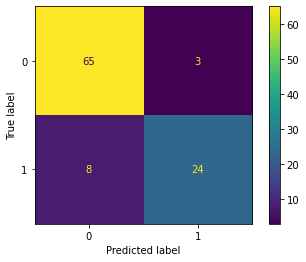

In [12]:
# p3.5: Make the Confusion Matrix and show the result
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

plot_confusion_matrix(classifier, X_test, y_test)  
plt.show()  

How do you decide which threshold to use? First, use the cross_val_predict()function to get the scores of all instances in the training set, but this time specify that you want to return decision scores instead of predictions:

In [13]:
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(classifier, X_train, y_train, cv = 3, method = 'decision_function')
#print(y_scores)

In [14]:
# Logistic Regression Classification metrics
# p3.6: Compute the accuracy, precision, recall and f1_score and show all results
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

ac = accuracy_score(y_test, y_pred)
pc = precision_score(y_test, y_pred)
rs = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy score:  ", ac)
print("Precision score: ", pc)
print("Recall score:    ", rs)
print("f1 score:        ", f1)

Accuracy score:   0.89
Precision score:  0.8888888888888888
Recall score:     0.75
f1 score:         0.8135593220338982


In [15]:
# p3.7: use the precision_recall_curve() function to compute precision and recall for all possible thresholds
from sklearn.metrics import precision_recall_curve

#precision, recall, threshold = precision_recall_curve(y_test, y_pred)
precision, recall, threshold = precision_recall_curve(y_train, y_scores)

#print("Precision: ", precision)
#print("Recall:    ", recall)
#print("Threshold: ", threshold)

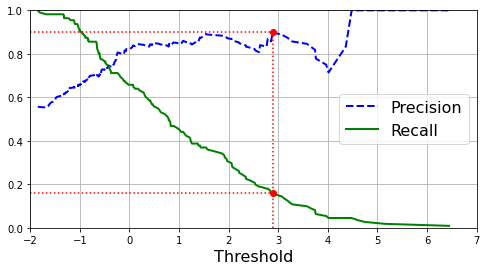

In [16]:
# p3.8: Use Matplotlib to plot precision and recall as functions of the threshold value
#from sklearn.metrics import plot_precision_recall_curve
#from sklearn.metrics import average_precision_score

#average_precision = average_precision_score(y_test, y_pred)

#disp = plot_precision_recall_curve(classifier, X_test, y_test)
#disp.ax_.set_title('2-class Precision-Recall curve: '
#                   'AP={0:0.2f}'.format(average_precision))


# SOLUTION

def plot_precision_recall_vs_threshold(precision, recall, threshold):
    plt.plot(threshold, precision[:-1], "b--", label = "Precision", linewidth = 2)
    plt.plot(threshold, recall[:-1], "g-", label = "Recall", linewidth = 2)
    plt.legend(loc = "center right", fontsize = 16) 
    plt.xlabel("Threshold", fontsize = 16)        
    plt.grid(True)                              
    plt.axis([-2, 7, 0, 1])             

recall_90_precision = recall[np.argmax(precision >= 0.90)]
threshold_90_precision = threshold[np.argmax(precision >= 0.90)]

plt.figure(figsize=(8, 4))                                                                  
plot_precision_recall_vs_threshold(precision, recall, threshold)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 
plt.plot([-2, threshold_90_precision], [0.9, 0.9], "r:")                                
plt.plot([-2, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")                                             
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             
plt.show()

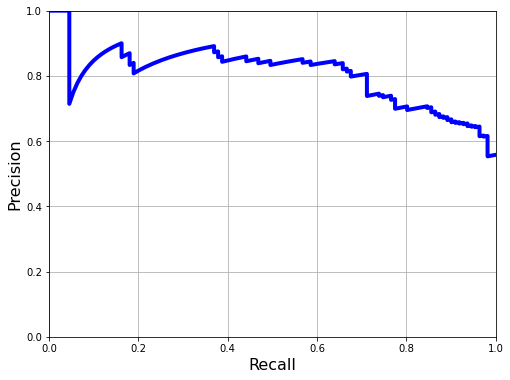

In [17]:
# p3.9: Visualise the Plot precision_vs_recall plot

def plot_precision_vs_recall(precision, recall):
    plt.plot(recall, precision, "b-", linewidth = 4)
    plt.xlabel("Recall", fontsize = 16)
    plt.ylabel("Precision", fontsize = 16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precision, recall)
plt.show()

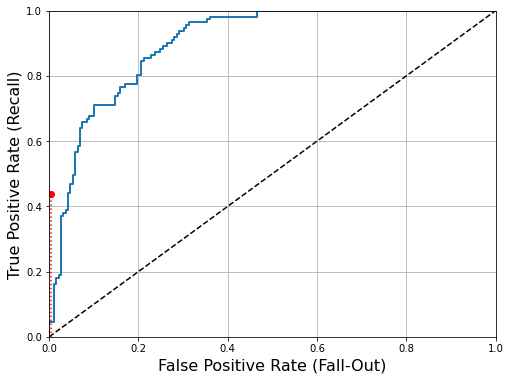

In [18]:
# p3.10: plot the ROC curve
# you should first use the roc_curve() function to compute the TPR and FPR for various threshold values:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

def plot_roc_curve(fpr, tpr, label = None):
    plt.plot(fpr, tpr, linewidth = 2, label = label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])                                    
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize = 16) 
    plt.ylabel('True Positive Rate (Recall)', fontsize = 16)    
    plt.grid(True)                                            

plt.figure(figsize=(8, 6))                         
plot_roc_curve(fpr, tpr)
plt.plot([4.837e-3, 4.837e-3], [0., 0.4368], "r:") 
plt.plot([0.0, 4.837e-3], [0.4368, 0.4368], "r:")  
plt.plot([4.837e-3], [0.4368], "ro")               
plt.show()

In [19]:
# p3.11: Compute AUC score and show the result
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_train, y_scores)
print("AUC score: ", auc)

AUC score:  0.9016159016159017


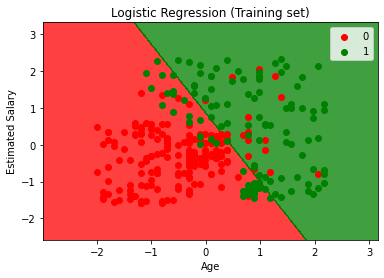

In [21]:
# Visualise the Training set results of Logistic Regression method
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color = ListedColormap(('red', 'green'))(i), label = j)
    
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

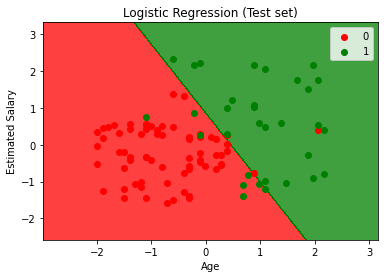

In [22]:
# Visualise the Training set results of Logistic Regression method
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color = ListedColormap(('red', 'green'))(i), label = j)
    
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()